# 07 · K-Means Clustering and PCA, Explained Visually

Companion notebook for the [lesson](https://github.com/younespuri/visual-machine-learning-for-beginners/blob/main/lessons/07-clustering-and-pca/README.md). Run the cells from top to bottom with **Shift + Enter**.

### Step 1 · Group customers with K-Means

In [1]:
import numpy as np
from sklearn.cluster import KMeans

# Each row is one customer: [age, spending score from 0 to 100]
customers = np.array([
    [22, 85],
    [25, 90],
    [23, 82],
    [45, 20],
    [48, 15],
    [50, 25],
    [24, 88],
    [47, 18],
])

kmeans = KMeans(n_clusters=2, n_init=10, random_state=42)
kmeans.fit(customers)                      # no labels: only the data itself

print(kmeans.labels_)
print(kmeans.cluster_centers_)
print(kmeans.predict([[30, 70], [55, 30]]))
# [0 0 0 1 1 1 0 1]
# [[23.5  86.25]
#  [47.5  19.5 ]]
# [0 1]

[0 0 0 1 1 1 0 1]
[[23.5  86.25]
 [47.5  19.5 ]]
[0 1]


- `fit` gets the customers and nothing else. In unsupervised learning, there's no `y`.
- `n_clusters=2` is k. `n_init=10` runs K-Means from 10 different random starts and keeps the best one (the lowest inertia), and `random_state=42` makes those starts repeatable.
- `labels_` holds each customer's cluster. `cluster_centers_` holds the final centroids, which are the "average customer" of each group: about 24 years old with a spending score of 86, and about 48 with a score of 20.
- `predict` sends new customers to their nearest centroid: the 30-year-old big spender joins cluster 0, and the careful 55-year-old joins cluster 1.
- The cluster numbers are only names. Cluster 0 isn't first or best, and another run may swap them.

### Step 2 · Choose k with the elbow method

In [2]:
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score

X, _ = make_blobs(n_samples=150, centers=3, random_state=38)   # "_" throws away the true groups

for k in range(1, 9):
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
    line = f"k = {k}   inertia = {km.inertia_:5.0f}"
    if k > 1:                                                   # silhouette needs 2+ clusters
        line += f"   silhouette = {silhouette_score(X, km.labels_):.2f}"
    print(line)
# k = 1   inertia =  3842
# k = 2   inertia =  1347   silhouette = 0.59
# k = 3   inertia =   325   silhouette = 0.70
# k = 4   inertia =   282   silhouette = 0.57
# k = 5   inertia =   238   silhouette = 0.47
# k = 6   inertia =   202   silhouette = 0.36
# k = 7   inertia =   172   silhouette = 0.35
# k = 8   inertia =   157   silhouette = 0.34

k = 1   inertia =  3842
k = 2   inertia =  1347   silhouette = 0.59
k = 3   inertia =   325   silhouette = 0.70
k = 4   inertia =   282   silhouette = 0.57
k = 5   inertia =   238   silhouette = 0.47
k = 6   inertia =   202   silhouette = 0.36
k = 7   inertia =   172   silhouette = 0.35
k = 8   inertia =   157   silhouette = 0.34


- `make_blobs` generates points around a few centers. These are the same 150 points as in the animation and the elbow chart. It also returns which center each point came from, but we throw that away and pretend we never had it.
- Inertia falls by about 2,500 from k = 1 to 2 and by about 1,000 from 2 to 3, then by only about 40 from 3 to 4. That's the elbow: k = 3.
- The silhouette score peaks at k = 3 too. When both methods agree, you can pick k with confidence.
- `km.inertia_` is the inertia of a fitted model, and `silhouette_score` needs the data plus the cluster labels.

### Step 3 · Scale before you cluster

In [3]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

rng = np.random.default_rng(0)
# 20 young people, 20 mid-career people and 20 retirees (incomes in $1,000s)
ages = np.concatenate([rng.normal(22, 2, 20), rng.normal(40, 3, 20), rng.normal(68, 3, 20)])
incomes = np.concatenate([rng.normal(25, 8, 20), rng.normal(90, 12, 20), rng.normal(30, 8, 20)])
people = pd.DataFrame({"age": ages.round().astype(int),
                       "income": incomes.round().astype(int) * 1000})

kmeans_3 = KMeans(n_clusters=3, n_init=10, random_state=42)
raw = kmeans_3.fit_predict(people)                                      # years vs. dollars
scaled = kmeans_3.fit_predict(StandardScaler().fit_transform(people))   # both standardized

for name, labels in [("Without scaling:", raw), ("With scaling:", scaled)]:
    summary = people.groupby(labels).agg(youngest=("age", "min"), oldest=("age", "max"),
                                         avg_income=("income", "mean"))
    print(name)
    print(summary.round().astype(int))
# Without scaling:
#    youngest  oldest  avg_income
# 0        37      44       89100
# 1        17      74       34750
# 2        19      73       19938
# With scaling:
#    youngest  oldest  avg_income
# 0        37      44       89100
# 1        64      74       30650
# 2        17      25       27000

Without scaling:
   youngest  oldest  avg_income
0        37      44       89100
1        17      74       34750
2        19      73       19938
With scaling:
   youngest  oldest  avg_income
0        37      44       89100
1        64      74       30650
2        17      25       27000


- The data hides three groups: young people and retirees who both earn little, and mid-career people who earn a lot. `rng.normal(mean, spread, count)` draws random numbers around a mean.
- Each cluster's youngest and oldest member tell the story. Without scaling, two clusters each hold people from about 17 to 74 years old: K-Means split everyone by income alone, because income differences are over a thousand times bigger than age differences.
- `StandardScaler` rescales each column to mean 0 and standard deviation 1. Now age counts as much as income, and the three real groups come back: young people, mid-career people and retirees.
- `fit_predict` is `fit` plus `labels_` in one call.
- With real customers you wouldn't know the hidden groups, so you couldn't check like this. That's exactly why you scale by default before any method built on distances.

### Step 4 · Squeeze 64 pixels into 2 numbers with PCA

In [4]:
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA

digits = load_digits()
print(digits.data.shape)                   # 1,797 images, each 8 x 8 = 64 pixels

pca = PCA(n_components=2)
X_2d = pca.fit_transform(digits.data)
print(X_2d.shape)
print(pca.explained_variance_ratio_.round(3))
print(pca.explained_variance_ratio_.sum().round(3))
# (1797, 64)
# (1797, 2)
# [0.149 0.136]
# 0.285

(1797, 64)
(1797, 2)
[0.149 0.136]
0.285


- Each image is 64 numbers: the brightness of every pixel, from 0 (blank) to 16 (full ink). So each image has 64 features.
- `fit_transform` does two jobs in one call: `fit` finds the components, and `transform` projects every image onto them. 64 columns go in, 2 come out.
- PC1 keeps 14.9% of the variance and PC2 keeps 13.6%, so 28.5% together. That's not much, but as you'll see next, it's enough to tell some digits apart.
- All 64 features share one unit (pixel brightness), so there's no need to scale here.

### Step 5 · See the digits in 2-D

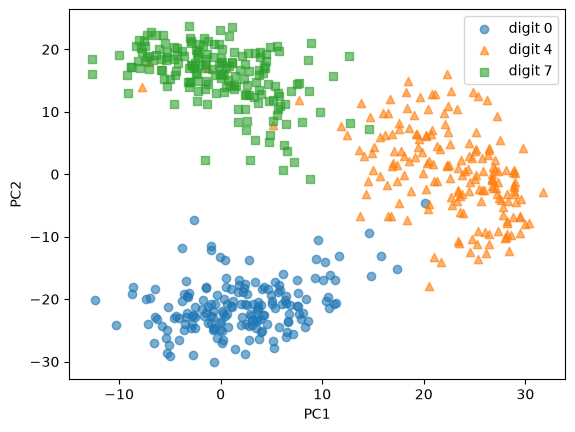

In [5]:
import matplotlib.pyplot as plt

for digit, marker in [(0, "o"), (4, "^"), (7, "s")]:
    points = X_2d[digits.target == digit]
    plt.scatter(points[:, 0], points[:, 1], marker=marker, alpha=0.6, label=f"digit {digit}")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

- You should see the picture from earlier in this lesson: the 0s at the bottom, the 7s at the top and the 4s off to the right.
- `digits.target` holds the real digit of each image. It's used here only to color the plot, after PCA has done its work. PCA never saw it.
- Try the digits 5 and 8 instead: they land almost on top of each other. Two components aren't enough to separate every digit.

### Step 6 · How many components should you keep?

In [6]:
pca_all = PCA().fit(digits.data)                 # keep all 64 components
running_total = np.cumsum(pca_all.explained_variance_ratio_)

for goal in (0.5, 0.8, 0.9, 0.95):
    n = np.argmax(running_total >= goal) + 1     # the first count that reaches the goal
    print(f"{goal:.0%} of the variance -> {n} components")
# 50% of the variance -> 5 components
# 80% of the variance -> 13 components
# 90% of the variance -> 21 components
# 95% of the variance -> 29 components

50% of the variance -> 5 components
80% of the variance -> 13 components
90% of the variance -> 21 components
95% of the variance -> 29 components


- `np.cumsum` gives a running total: the first value is PC1's share, the second is PC1 plus PC2, and so on.
- `np.argmax(running_total >= goal)` finds the first position where the total reaches the goal. Adding 1 turns that position into a count.
- 95% of the variance fits in 29 numbers instead of 64, less than half. The last components carry very little: mostly tiny details and noise.
- Shortcut: `PCA(n_components=0.95)` picks that number for you.

### Step 7 · Scale before PCA, too

In [7]:
from sklearn.datasets import load_wine

wine = load_wine()
X_wine = wine.data                               # 178 wines, 13 chemical measurements each

raw_pca = PCA(n_components=2).fit(X_wine)
scaled_pca = PCA(n_components=2).fit(StandardScaler().fit_transform(X_wine))

print("without scaling:", raw_pca.explained_variance_ratio_.round(3))
print("with scaling:   ", scaled_pca.explained_variance_ratio_.round(3))
top = np.abs(raw_pca.components_[0]).argmax()   # the feature with the biggest weight in PC1
print("PC1 without scaling is mostly:", wine.feature_names[top])
# without scaling: [0.998 0.002]
# with scaling:    [0.362 0.192]
# PC1 without scaling is mostly: proline

without scaling: [0.998 0.002]
with scaling:    [0.362 0.192]
PC1 without scaling is mostly: proline


- Most measurements in this dataset are small numbers. The wine's hue, for example, runs from about 0.5 to 1.7. But **proline** runs from 278 to 1,680.
- Without scaling, PC1 claims 99.8% of the variance and points almost straight along proline. PCA hasn't found a pattern; it has found the feature with the biggest numbers.
- `components_[0]` is PC1's recipe: one weight per original feature. The weight with the biggest size shows which feature PC1 mostly follows.
- After scaling, the variance is shared out fairly, 36% and 19%, and both components now mix many measurements.

### Step 8 · PCA and K-Means together

In [8]:
from sklearn.pipeline import make_pipeline

model = make_pipeline(
    StandardScaler(),                                   # 1. put all 13 features on the same scale
    PCA(n_components=2),                                # 2. squeeze them into 2 numbers
    KMeans(n_clusters=3, n_init=10, random_state=42),   # 3. find 3 groups
)
clusters = model.fit_predict(X_wine)

print(pd.crosstab(wine.target, clusters, rownames=["wine type"], colnames=["cluster"]))
# cluster     0   1   2
# wine type
# 0          59   0   0
# 1           5   1  65
# 2           0  48   0

cluster     0   1   2
wine type            
0          59   0   0
1           5   1  65
2           0  48   0


- `make_pipeline` chains the steps, so each one's output is the next one's input. It's the same pipeline idea as in lesson 05, now with PCA and K-Means as steps.
- K-Means never saw `wine.target`, the real grape variety of each wine. We use it only afterwards, to check.
- Each variety landed almost entirely in a cluster of its own: 172 of the 178 wines. From chemistry alone, with no labels, the pipeline rediscovered the three grape varieties.
- Why PCA first? With many features, K-Means gets slower, and distances between points start to look alike, which makes "nearest" less meaningful. Two components kept the structure that K-Means needed.

### Bonus · K-Means in 10 lines of NumPy

In [9]:
rng = np.random.default_rng(4)
centroids = X[rng.choice(len(X), size=3, replace=False)]        # 3 random points to start

for step in range(1, 21):
    distances = np.linalg.norm(X[:, None] - centroids, axis=2)   # every point to every centroid
    labels = distances.argmin(axis=1)                            # 1. assign: nearest centroid wins
    inertia = (distances.min(axis=1) ** 2).sum()
    print(f"step {step}:  inertia = {inertia:6.1f}")
    new_centroids = np.array([X[labels == j].mean(axis=0) for j in range(3)])  # 2. move
    if np.allclose(new_centroids, centroids):                    # nothing moved: done
        break
    centroids = new_centroids

print("scikit-learn:", round(KMeans(n_clusters=3, n_init=10, random_state=42).fit(X).inertia_, 1))
# step 1:  inertia = 4158.9
# step 2:  inertia = 1362.7
# step 3:  inertia = 1136.8
# step 4:  inertia =  649.9
# step 5:  inertia =  328.9
# step 6:  inertia =  324.6
# scikit-learn: 324.6

step 1:  inertia = 4158.9
step 2:  inertia = 1362.7
step 3:  inertia = 1136.8
step 4:  inertia =  649.9
step 5:  inertia =  328.9
step 6:  inertia =  324.6
scikit-learn: 324.6


- `X[:, None] - centroids` subtracts every centroid from every point in one go, giving a stack of shape (150, 3, 2). `np.linalg.norm(..., axis=2)` turns each difference into a distance.
- Inertia only goes down, round after round, just as promised, and it ends at the same 324.6 as scikit-learn.
- Change the seed in `default_rng(4)`. Most starts reach 324.6, some in fewer steps, but an unlucky start can get stuck higher. That's why scikit-learn runs 10 starts with `n_init=10`.